In [1]:
import numpy as np
import heapq
import math
import matplotlib.pyplot as plt


In [2]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius (km)
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1-a))


In [3]:
def compute_ground_speed(v_air, u_wind, v_wind, dx, dy):
    # Unit direction vector of movement
    norm = math.sqrt(dx**2 + dy**2)
    ux, uy = dx / norm, dy / norm

    # Airspeed vector
    vax, vay = v_air * ux, v_air * uy

    # Ground speed vector
    vg_x = vax + u_wind
    vg_y = vay + v_wind

    return math.sqrt(vg_x**2 + vg_y**2)


In [4]:
class Node:
    def __init__(self, lat_idx, lon_idx):
        self.lat = lat_idx
        self.lon = lon_idx

    def __lt__(self, other):
        return False


In [5]:
def heuristic(node, goal, lat_grid, lon_grid, wind_u, wind_v, v_air):
    lat1, lon1 = lat_grid[node.lat], lon_grid[node.lon]
    lat2, lon2 = lat_grid[goal.lat], lon_grid[goal.lon]

    d = haversine(lat1, lon1, lat2, lon2)

    u = wind_u[node.lat, node.lon]
    v = wind_v[node.lat, node.lon]

    v_ground = max(compute_ground_speed(v_air, u, v, 1, 1), 50)
    return d / v_ground


In [6]:
def step_cost(curr, nxt, lat_grid, lon_grid, wind_u, wind_v, v_air):
    lat1, lon1 = lat_grid[curr.lat], lon_grid[curr.lon]
    lat2, lon2 = lat_grid[nxt.lat], lon_grid[nxt.lon]

    d = haversine(lat1, lon1, lat2, lon2)

    dx = nxt.lat - curr.lat
    dy = nxt.lon - curr.lon

    u = wind_u[curr.lat, curr.lon]
    v = wind_v[curr.lat, curr.lon]

    v_ground = max(compute_ground_speed(v_air, u, v, dx, dy), 50)
    return d / v_ground


In [7]:
def astar(start, goal, lat_grid, lon_grid, wind_u, wind_v, v_air):
    open_set = []
    heapq.heappush(open_set, (0, start))

    came_from = {}
    g_cost = { (start.lat, start.lon): 0 }

    moves = [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]

    while open_set:
        _, current = heapq.heappop(open_set)

        if (current.lat, current.lon) == (goal.lat, goal.lon):
            path = []
            while (current.lat, current.lon) in came_from:
                path.append((current.lat, current.lon))
                current = came_from[(current.lat, current.lon)]
            path.append((start.lat, start.lon))
            return path[::-1]

        for dx, dy in moves:
            ni, nj = current.lat + dx, current.lon + dy
            if ni < 0 or nj < 0 or ni >= len(lat_grid) or nj >= len(lon_grid):
                continue

            neighbor = Node(ni, nj)
            tentative_g = g_cost[(current.lat, current.lon)] + \
                           step_cost(current, neighbor, lat_grid, lon_grid, wind_u, wind_v, v_air)

            key = (ni, nj)
            if key not in g_cost or tentative_g < g_cost[key]:
                g_cost[key] = tentative_g
                f = tentative_g + heuristic(neighbor, goal, lat_grid, lon_grid, wind_u, wind_v, v_air)
                heapq.heappush(open_set, (f, neighbor))
                came_from[key] = current

    return None


In [11]:
# Load preprocessed test data
X_test = np.load('data/processed/X_test.npy')
Y_test = np.load('data/processed/Y_test.npy')
mean = np.load("data/processed/mean.npy")
std = np.load("data/processed/std.npy")

# Load pre-trained PredRNN model
import torch
import torch.nn as nn

class PredRNNCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size):
        super().__init__()
        padding = kernel_size // 2
        self.hidden_dim = hidden_dim
        self.conv_xh = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim, kernel_size, padding=padding)
        self.conv_m = nn.Conv2d(hidden_dim, 3 * hidden_dim, kernel_size, padding=padding)

    def forward(self, x, h_prev, c_prev, m_prev):
        combined = torch.cat([x, h_prev], dim=1)
        gates = self.conv_xh(combined)
        i, f, g, o = torch.chunk(gates, 4, dim=1)
        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        g = torch.tanh(g)
        o = torch.sigmoid(o)
        c = f * c_prev + i * g
        m_gates = self.conv_m(m_prev)
        mi, mf, mg = torch.chunk(m_gates, 3, dim=1)
        mi = torch.sigmoid(mi)
        mf = torch.sigmoid(mf)
        mg = torch.tanh(mg)
        m = mf * m_prev + mi * mg
        h = o * torch.tanh(c + m)
        return h, c, m

class PredRNN(nn.Module):
    def __init__(self, input_dim, hidden_dims, kernel_size, num_layers, out_steps):
        super().__init__()
        self.num_layers = num_layers
        self.out_steps = out_steps
        self.cells = nn.ModuleList([
            PredRNNCell(input_dim if i == 0 else hidden_dims[i-1], hidden_dims[i], kernel_size)
            for i in range(num_layers)
        ])
        self.conv_out = nn.Conv2d(hidden_dims[-1], input_dim, kernel_size=1)

    def forward(self, x, teacher_forcing_ratio=0.0):
        B, Tin, C, H, W = x.shape
        device = x.device
        h = [torch.zeros(B, cell.hidden_dim, H, W, device=device) for cell in self.cells]
        c = [torch.zeros_like(h_i) for h_i in h]
        m = [torch.zeros_like(h_i) for h_i in h]
        outputs = []
        prev = x[:, -1]
        for t in range(self.out_steps):
            inp = prev
            for l, cell in enumerate(self.cells):
                h[l], c[l], m[l] = cell(inp, h[l], c[l], m[l])
                inp = h[l]
            frame = self.conv_out(inp)
            outputs.append(frame)
            prev = frame.detach()
        return torch.stack(outputs, dim=1)

# Load model
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PredRNN(input_dim=2, hidden_dims=[64, 64, 64], kernel_size=3, num_layers=3, out_steps=Y_test.shape[1]).to(DEVICE)

# Load checkpoint (extract model_state from the full checkpoint)
checkpoint = torch.load('checkpoints/predrnn_best.pt', map_location=DEVICE)
if isinstance(checkpoint, dict) and 'model_state' in checkpoint:
    model.load_state_dict(checkpoint['model_state'])
else:
    model.load_state_dict(checkpoint)
model.eval()

# Generate wind predictions
with torch.no_grad():
    x_test_tensor = torch.from_numpy(X_test[:1]).float().to(DEVICE)  # Use first test sample
    preds = model(x_test_tensor, teacher_forcing_ratio=0.0).cpu().numpy()

# Denormalize predictions
preds = preds * std.reshape(1, 1, 2, 1, 1) + mean.reshape(1, 1, 2, 1, 1)

# Extract U and V components for first time step
pred_u = preds[0, 0, 0, :, :]  # U component at first predicted time step
pred_v = preds[0, 0, 1, :, :]  # V component at first predicted time step

print(f"Wind data shape: {pred_u.shape}")

# Grid must match wind data dimensions
H, W = pred_u.shape
lat_grid = np.linspace(6, 38, H)
lon_grid = np.linspace(68, 98, W)

# Adjusted Delhi → Mumbai coordinates (scale to match wind grid dimensions)
# Original: lat_idx=150, lon_idx=120 on 201x281 grid
# New scale: (150/201)*H, (120/281)*W
start = Node(int((150/201)*H), int((120/281)*W))
goal  = Node(int((80/201)*H), int((100/281)*W))

print(f"Start: {start.lat}, {start.lon}")
print(f"Goal: {goal.lat}, {goal.lon}")

route = astar(start, goal, lat_grid, lon_grid, pred_u, pred_v, v_air=230)
print("Route length:", len(route))


C:\Users\DELL\AppData\Local\Temp\ipykernel_9656\1788909313.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('checkpoints/predrnn_best.pt', map_lo

Wind data shape: (141, 141)
Start: 105, 60
Goal: 56, 50
Route length: 50


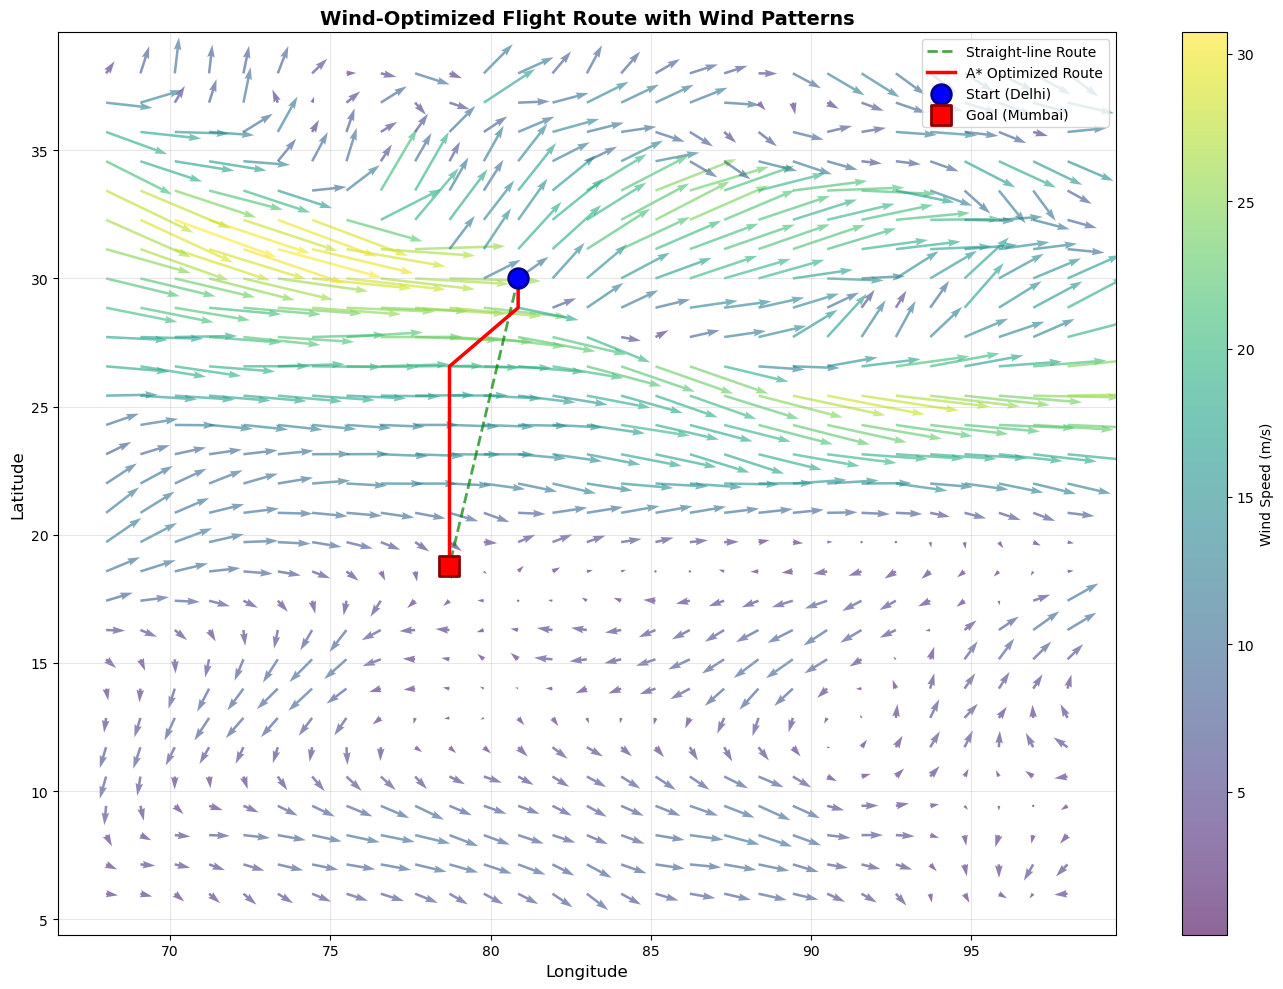


Route Statistics:
Straight-line distance: 1264.05 km
Straight-line travel time: 5.68 hours (5h 41m)

A* optimized route distance: 1321.51 km
A* optimized route travel time: 6.06 hours (6h 3m)

Distance difference: +57.46 km (+4.5%)
Time saved: -0.37 hours (0h 22m)


In [14]:
lats = [lat_grid[i] for i, j in route]
lons = [lon_grid[j] for i, j in route]

# Create a comprehensive plot with wind patterns
fig, ax = plt.subplots(figsize=(14, 10))

# Plot wind field as quiver (vector arrows)
# Subsample for clarity
skip = 5  # Plot every 5th vector
lat_indices = np.arange(0, pred_u.shape[0], skip)
lon_indices = np.arange(0, pred_u.shape[1], skip)
lat_mesh, lon_mesh = np.meshgrid(lat_indices, lon_indices, indexing='ij')

# Get corresponding lat/lon coordinates
lat_coords = lat_grid[lat_indices]
lon_coords = lon_grid[lon_indices]
lat_mesh_coords, lon_mesh_coords = np.meshgrid(lat_coords, lon_coords, indexing='ij')

# Wind components
u_sub = pred_u[lat_indices][:, lon_indices]
v_sub = pred_v[lat_indices][:, lon_indices]

# Plot wind vectors
quiver = ax.quiver(lon_mesh_coords, lat_mesh_coords, u_sub, v_sub, 
                   np.sqrt(u_sub**2 + v_sub**2), cmap='viridis', alpha=0.6, scale=300)
cbar = plt.colorbar(quiver, ax=ax, label='Wind Speed (m/s)')

# Plot straight-line baseline route
straight_start_lat = lat_grid[start.lat]
straight_start_lon = lon_grid[start.lon]
straight_goal_lat = lat_grid[goal.lat]
straight_goal_lon = lon_grid[goal.lon]
ax.plot([straight_start_lon, straight_goal_lon], [straight_start_lat, straight_goal_lat], 
        'g--', linewidth=2, label="Straight-line Route", alpha=0.7)

# Plot optimized A* route
ax.plot(lons, lats, 'r-', linewidth=2.5, label="A* Optimized Route", zorder=5)

# Mark start and goal
ax.scatter([straight_start_lon], [straight_start_lat], c='blue', s=200, marker='o', 
          edgecolors='darkblue', linewidth=2, label='Start (Delhi)', zorder=10)
ax.scatter([straight_goal_lon], [straight_goal_lat], c='red', s=200, marker='s', 
          edgecolors='darkred', linewidth=2, label='Goal (Mumbai)', zorder=10)

ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.set_title("Wind-Optimized Flight Route with Wind Patterns", fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate and display route statistics
straight_distance = haversine(straight_start_lat, straight_start_lon, 
                              straight_goal_lat, straight_goal_lon)

# Calculate travel time for straight-line route
u_start = pred_u[start.lat, start.lon]
v_start = pred_v[start.lat, start.lon]
dx_straight = goal.lon - start.lon
dy_straight = goal.lat - start.lat
straight_ground_speed = compute_ground_speed(230, u_start, v_start, dx_straight, dy_straight)
straight_time = straight_distance / straight_ground_speed  # in hours

# Calculate travel time for A* optimized route
optimized_distance = 0
optimized_time = 0
for i in range(len(route)-1):
    lat1, lon1 = lat_grid[route[i][0]], lon_grid[route[i][1]]
    lat2, lon2 = lat_grid[route[i+1][0]], lon_grid[route[i+1][1]]
    
    # Distance for this segment
    seg_distance = haversine(lat1, lon1, lat2, lon2)
    optimized_distance += seg_distance
    
    # Ground speed for this segment
    u = pred_u[route[i][0], route[i][1]]
    v = pred_v[route[i][0], route[i][1]]
    dx = route[i+1][0] - route[i][0]
    dy = route[i+1][1] - route[i][1]
    seg_ground_speed = compute_ground_speed(230, u, v, dx, dy)
    seg_time = seg_distance / seg_ground_speed  # in hours
    optimized_time += seg_time

print(f"\n{'='*60}")
print(f"Route Statistics:")
print(f"{'='*60}")
print(f"Straight-line distance: {straight_distance:.2f} km")
print(f"Straight-line travel time: {straight_time:.2f} hours ({int(straight_time)}h {int((straight_time % 1) * 60)}m)")
print(f"\nA* optimized route distance: {optimized_distance:.2f} km")
print(f"A* optimized route travel time: {optimized_time:.2f} hours ({int(optimized_time)}h {int((optimized_time % 1) * 60)}m)")
print(f"\n{'='*60}")
print(f"Distance difference: {optimized_distance - straight_distance:+.2f} km ({(optimized_distance/straight_distance - 1)*100:+.1f}%)")
print(f"Time saved: {straight_time - optimized_time:+.2f} hours ({int(abs(straight_time - optimized_time))}h {int((abs(straight_time - optimized_time) % 1) * 60)}m)")
print(f"{'='*60}")
